In [60]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [61]:
df.shape

(891, 12)

In [62]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [63]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [64]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Titanic Data Exploration

The dataset contains information about passengers such as age, sex, ticket, and survival.

There are missing values especially in:
Age
Cabin (many missing)
Embarked (few missing)

Cabin has a large number of missing values.
Age also has several missing values.

In [65]:
df["Age"].median()

np.float64(28.0)

In [66]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [67]:
df["Cabin"] = df["Cabin"].fillna("Unknown")

In [68]:
df["Embarked"].mode()

0    S
Name: Embarked, dtype: str

In [69]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [70]:
df["Fare"] = df["Fare"].replace(0, df["Fare"].median())

In [71]:
df = df.drop(columns=["Ticket"])

# Data Cleaning

Missing Age values were filled using the median because it is more robust than the mean.

Cabin column had too many missing values, so missing values were replaced with "Unknown".

Embarked had only a few missing values, so they were filled using the most common value (mode).

Some Fare values were zero, which is unrealistic, so they were replaced with the median.

Ticket column was dropped because it does not provide useful information for analysis.

In [72]:
df["Age"].mean()

np.float64(29.36158249158249)

In [73]:
df["Embarked"].mode()

0    S
Name: Embarked, dtype: str

# Basic Statistics

The average age of passengers is approximately XX years.

The most common embarkation port is X.

This means most passengers boarded from this location.

In [74]:
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")

In [75]:
df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [76]:
df.groupby("Title")["Survived"].mean().sort_values(ascending=False)

Title
Lady            1.000000
Ms              1.000000
Sir             1.000000
Mme             1.000000
the Countess    1.000000
Mlle            1.000000
Mrs             0.792000
Miss            0.697802
Master          0.575000
Major           0.500000
Col             0.500000
Dr              0.428571
Mr              0.156673
Capt            0.000000
Jonkheer        0.000000
Don             0.000000
Rev             0.000000
Name: Survived, dtype: float64

# Title Analysis

Titles such as Mrs and Miss have higher survival rates.

Mr has a lower survival rate.

This suggests that gender and social status affected survival.

In [77]:
df = pd.read_csv("../data/municipalities.csv", sep=";", encoding="latin1")

In [78]:
df.head()

Municipal key figures 1987-2023
Region        Information                                                            2023
WHOLE COUNTRY Population                                                          5603851
              Population change from the previous year, %                             0.7
              Persons aged under 15, %                                               14.9
              Persons aged 15 to 64, %                                               61.8

In [79]:
df.columns

Index(['Municipal key figures 1987-2023'], dtype='str')

In [80]:
df = pd.read_csv("../data/municipalities.csv", sep=";", encoding="latin1", header=1)

In [81]:
df.head()
df.columns


Index(['Region', 'Information', '2023'], dtype='str')

In [82]:
df["2023"] = pd.to_numeric(df["2023"], errors="coerce")

In [83]:
df_pivot = df.pivot_table(
    index="Region",
    columns="Information",
    values="2023"
).reset_index()

In [84]:
df_pivot.head()

Information,Region,"Excess of births, persons",Families,"Foreign citizens, %",Household-dwelling units,"Household-dwelling units living in terraced houses and detached houses, %","Intermunicipal migration gain/loss, persons","Persons aged 15 to 64, %","Persons aged 64 or over, %","Persons aged under 15, %",Population,"Population change from the previous year, %","Swedish-speaking, %"
0,AVI1 Southern Finland AVI,-3972.0,627467.0,9.6,1221306.0,39.7,1626.0,64.0,21.1,15.0,2417383.0,1.1,5.5
1,AVI2 Southwestern Finland AVI,-3448.0,186121.0,5.9,364349.0,55.7,183.0,60.5,25.5,14.0,702526.0,0.6,4.0
2,AVI3 Eastern Finland AVI,-4016.0,143032.0,3.5,287123.0,61.4,-1316.0,57.8,29.1,13.1,540425.0,0.0,0.1
3,AVI4 Western and Inland Finland AVI,-4469.0,329877.0,4.3,630250.0,56.3,1125.0,61.0,23.9,15.1,1248457.0,0.7,7.8
4,AVI5 Northern Finland AVI,-1015.0,126007.0,3.3,237893.0,63.5,-1612.0,60.5,22.5,16.9,488369.0,0.3,0.2


In [85]:
import sqlite3

conn = sqlite3.connect("municipalities.db")
df_pivot.to_sql("municipalities", conn, if_exists="replace", index=False)

530

In [86]:
q1 = pd.read_sql_query(
    "SELECT * FROM municipalities LIMIT 10",
    conn
)
q1

,Region,"Excess of births, persons",Families,"Foreign citizens, %",Household-dwelling units,"Household-dwelling units living in terraced houses and detached houses, %","Intermunicipal migration gain/loss, persons","Persons aged 15 to 64, %","Persons aged 64 or over, %","Persons aged under 15, %",Population,"Population change from the previous year, %","Swedish-speaking, %"
0,AVI1 Southern Finland AVI,-3972.0,627467.0,9.6,1221306.0,39.7,1626.0,64.0,21.1,15.0,2417383.0,1.1,5.5
1,AVI2 Southwestern Finland AVI,-3448.0,186121.0,5.9,364349.0,55.7,183.0,60.5,25.5,14.0,702526.0,0.6,4.0
2,AVI3 Eastern Finland AVI,-4016.0,143032.0,3.5,287123.0,61.4,-1316.0,57.8,29.1,13.1,540425.0,0.0,0.1
3,AVI4 Western and Inland Finland AVI,-4469.0,329877.0,4.3,630250.0,56.3,1125.0,61.0,23.9,15.1,1248457.0,0.7,7.8
4,AVI5 Northern Finland AVI,-1015.0,126007.0,3.3,237893.0,63.5,-1612.0,60.5,22.5,16.9,488369.0,0.3,0.2
5,AVI6 Lapland AVI,-1025.0,46111.0,3.3,89433.0,66.6,-12.0,58.5,27.3,14.2,176150.0,0.2,0.3
6,AVI7 State Department of Åland,-11.0,8339.0,12.2,14529.0,70.3,6.0,59.9,24.2,15.9,30541.0,0.6,85.4
7,Akaa,-105.0,4531.0,2.1,7995.0,71.7,-18.0,59.1,25.6,15.3,16405.0,-0.4,0.2
8,Alajärvi,-65.0,2522.0,4.0,4037.0,91.7,-124.0,53.1,30.8,16.2,9113.0,-0.8,0.2
9,Alavieska,-14.0,642.0,1.8,1095.0,97.5,-28.0,54.9,26.9,18.3,2437.0,-0.4,0.2


In [87]:
q2 = pd.read_sql_query(
    """
    SELECT Region, Population
    FROM municipalities
    ORDER BY Population DESC
    LIMIT 10
    """,
    conn
)
q2

,Region,Population
0,WHOLE COUNTRY,5603851.0
1,FI1 MAINLAND FINLAND,5573310.0
2,MA1 MAINLAND FINLAND,5573310.0
3,TK1 Urban municipalities,4096477.0
4,AVI1 Southern Finland AVI,2417383.0
5,HO1 Helsinki Court of Appeal,1764602.0
6,ELY01 Uusimaa ELY Centre,1759537.0
7,FI1B Helsinki-Uusimaa,1759537.0
8,FI1B1 Helsinki-Uusimaa,1759537.0
9,MK01 Uusimaa,1759537.0


In [88]:
q3 = pd.read_sql_query(
    """
    SELECT COUNT(*) AS total_rows
    FROM municipalities
    """,
    conn
)
q3

,total_rows
0,530


## SQL query comments

The first query shows example rows from the SQLite table.

The second query shows the municipalities with the highest population values.

The third query shows how many rows the SQLite table contains.

In [89]:
rovaniemi = df_pivot[df_pivot["Region"] == "Rovaniemi"]
rovaniemi

Information,Region,"Excess of births, persons",Families,"Foreign citizens, %",Household-dwelling units,"Household-dwelling units living in terraced houses and detached houses, %","Intermunicipal migration gain/loss, persons","Persons aged 15 to 64, %","Persons aged 64 or over, %","Persons aged under 15, %",Population,"Population change from the previous year, %","Swedish-speaking, %"
359,Rovaniemi,-42.0,16699.0,3.6,33938.0,49.4,178.0,63.4,21.0,15.6,65286.0,1.2,0.2


In [90]:
df_pivot.select_dtypes(include="number").columns

Index(['Excess of births, persons', 'Families', 'Foreign citizens, %',
       'Household-dwelling units',
       'Household-dwelling units living in terraced houses and detached houses, %',
       'Intermunicipal migration gain/loss, persons',
       'Persons aged 15 to 64, %', 'Persons aged 64 or over, %',
       'Persons aged under 15, %', 'Population',
       'Population change from the previous year, %', 'Swedish-speaking, %'],
      dtype='str', name='Information')

In [91]:
corr_value = rovaniemi[["Population", "Population change from the previous year, %"]].corr(method="pearson")
corr_value

Information,Population,"Population change from the previous year, %"
Information,,
Population,NaN,NaN
"Population change from the previous year, %",NaN,NaN


## Correlation comment

The correlation shows whether the selected variables move in the same direction or in opposite directions.

A positive correlation means both tend to increase together.

A negative correlation means one tends to increase when the other decreases.

In [92]:
import matplotlib.pyplot as plt

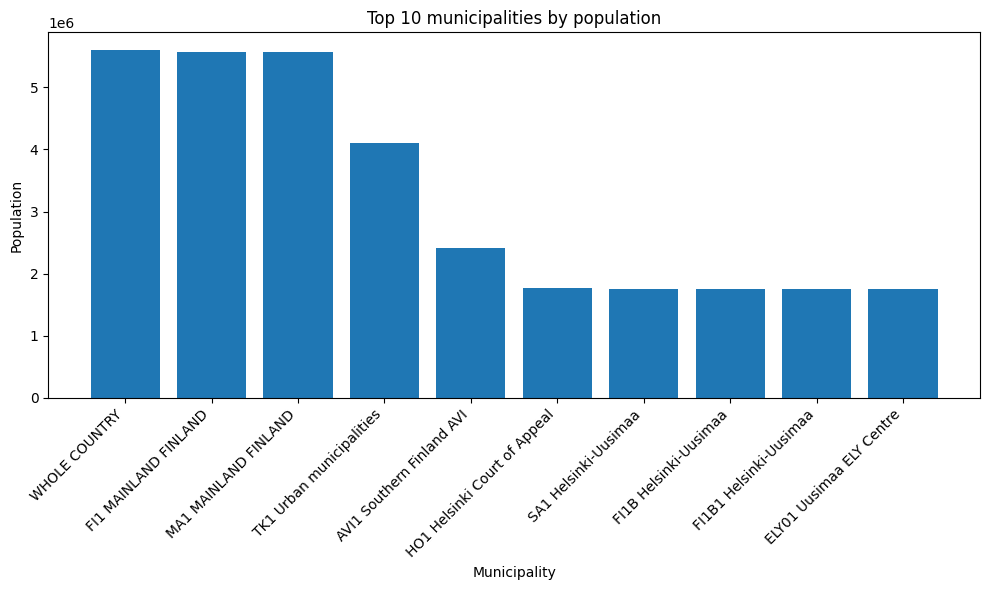

In [93]:
top_population = df_pivot.sort_values("Population", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_population["Region"], top_population["Population"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 municipalities by population")
plt.xlabel("Municipality")
plt.ylabel("Population")
plt.tight_layout()
plt.show()

In [94]:
if "Persons aged 65 or over, %" in df_pivot.columns:
    top_old = df_pivot.sort_values("Persons aged 65 or over, %", ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    plt.bar(top_old["Region"], top_old["Persons aged 65 or over, %"])
    plt.xticks(rotation=45, ha="right")
    plt.title("Top 10 municipalities by share of population aged 65 or over")
    plt.xlabel("Municipality")
    plt.ylabel("Percentage")
    plt.tight_layout()
    plt.show()

In [95]:
import seaborn as sns

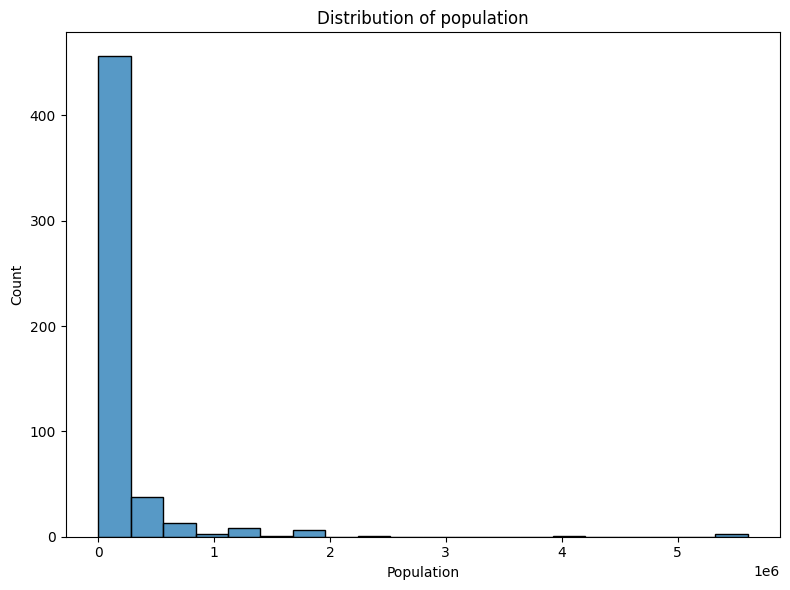

In [96]:
plt.figure(figsize=(8, 6))
sns.histplot(df_pivot["Population"], bins=20)
plt.title("Distribution of population")
plt.xlabel("Population")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [97]:
if "Persons aged under 15, %" in df_pivot.columns and "Persons aged 65 or over, %" in df_pivot.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_pivot,
        x="Persons aged under 15, %",
        y="Persons aged 65 or over, %"
    )
    plt.title("Share of young population vs share of elderly population")
    plt.xlabel("Persons aged under 15, %")
    plt.ylabel("Persons aged 65 or over, %")
    plt.tight_layout()
    plt.show()

## Reflection

This assignment helped me understand how to clean and transform data into a more useful format.

I learned how to save a pandas DataFrame into SQLite and query it with SQL.

I also practiced correlation analysis and data visualization with both Matplotlib and Seaborn.

The visualizations helped me understand differences between municipalities more clearly.

Overall, this assignment improved my confidence in working with real datasets.